# 08 – Backtest Advanced School Run Strategy (Tom Hougaard)

**Instrument** : DAX 40 Futures (DE40), 5-min data  
**Data** : `data/dax-5m_bk.csv` — 2000 to 2025

## Strategy Rules
1. **Signal Bar** = 4th 5-min candle after 9:00 CET open → opens at **09:15**, closes at **09:20** CET
2. **Entry orders** set after signal bar closes:
   - Long  : Buy Stop at `signal_high + 2`
   - Short : Sell Stop at `signal_low − 2`
   - First order triggered cancels the other (OCO)
3. **Stop Loss** — always the opposite order's price:
   - Long stop  : `signal_low − 2` (the short entry level)
   - Short stop : `signal_high + 2` (the long entry level)
   - Risk = signal bar range + 4 points
4. **No profit target** — let the trade run until stop hit or EOD
5. **Exit** : End-of-day at **17:30 CET** if no stop hit
6. **5th Bar Fallback** : If the 4th bar range is narrow (< `NARROW_THRESHOLD` pts), use the 5th bar (09:20) as signal

## What this notebook quantifies
- Win rate, avg win/loss, profit factor, Sharpe, max drawdown
- Long vs short breakdown
- 4th bar vs 5th bar fallback comparison
- Performance by year and by month
- Signal bar size distribution & edge
- Day-of-week performance
- Adverse & favorable excursion analysis

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Load & Prepare Data

In [2]:
DATA_PATH = ROOT / 'data' / 'dax-5m_bk.csv'

raw = pd.read_csv(
    DATA_PATH,
    sep=';',
    header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)

raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()

START_DATE = '2006-01-01'
raw = raw[raw.index >= START_DATE]

print(f'Loaded {len(raw):,} rows from {raw.index[0].date()} to {raw.index[-1].date()}')
raw.head()

Loaded 998,622 rows from 2006-01-02 to 2026-04-06


,open,high,low,close,volume
datetime,,,,,
2006-01-02 01:55:00,5768.884573,5772.061271,5762.001726,5763.060625,1059
2006-01-02 02:00:00,5763.590075,5769.943472,5762.001726,5762.531176,1121
2006-01-02 02:05:00,5763.590075,5773.120171,5762.531176,5773.120171,812
2006-01-02 02:10:00,5773.120171,5779.473568,5772.590721,5776.826319,891
2006-01-02 02:15:00,5777.355769,5779.473568,5774.708520,5778.944118,864


## 2. Strategy Parameters

In [3]:
ENTRY_BUFFER      = 2       # points beyond signal bar high/low
EOD_EXIT_TIME     = '17:30' # end-of-day exit time (CET)

# 4th bar = opens at 09:15 (candles: 09:00, 09:05, 09:10, 09:15)
SIGNAL_BAR_4      = '09:15'
# 5th bar fallback = opens at 09:20
SIGNAL_BAR_5      = '09:20'
# If 4th bar range < this threshold, use 5th bar instead
NARROW_THRESHOLD  = 10      # points

print('Parameters set.')
print(f'  Entry buffer      : {ENTRY_BUFFER} pts')
print(f'  EOD exit          : {EOD_EXIT_TIME} CET')
print(f'  Signal bar (4th)  : {SIGNAL_BAR_4} CET (closes 09:20)')
print(f'  Signal bar (5th)  : {SIGNAL_BAR_5} CET (closes 09:25) — fallback')
print(f'  Narrow threshold  : {NARROW_THRESHOLD} pts (triggers 5th bar fallback)')

Parameters set.
  Entry buffer      : 2 pts
  EOD exit          : 17:30 CET
  Signal bar (4th)  : 09:15 CET (closes 09:20)
  Signal bar (5th)  : 09:20 CET (closes 09:25) — fallback
  Narrow threshold  : 10 pts (triggers 5th bar fallback)


## 3. Identify Signal Bars

In [4]:
# Extract 4th and 5th bars for each trading day
bars_4th = raw[raw.index.strftime('%H:%M') == SIGNAL_BAR_4].copy()
bars_5th = raw[raw.index.strftime('%H:%M') == SIGNAL_BAR_5].copy()

bars_4th['bar_range'] = bars_4th['high'] - bars_4th['low']
bars_5th['bar_range'] = bars_5th['high'] - bars_5th['low']

# Data quality filter
bars_4th = bars_4th[(bars_4th['bar_range'] > 0.1) & (bars_4th['bar_range'] < 500)]
bars_5th = bars_5th[(bars_5th['bar_range'] > 0.1) & (bars_5th['bar_range'] < 500)]

bars_4th['trade_date'] = bars_4th.index.date
bars_5th['trade_date'] = bars_5th.index.date

# Index by trade_date for fast lookup
bars_4th_by_date = bars_4th.set_index('trade_date')
bars_5th_by_date = bars_5th.set_index('trade_date')

print(f'4th bar days found : {len(bars_4th):,}')
print(f'5th bar days found : {len(bars_5th):,}')
print(f'Narrow days (4th bar < {NARROW_THRESHOLD} pts): '
      f'{(bars_4th["bar_range"] < NARROW_THRESHOLD).sum():,} '
      f'({(bars_4th["bar_range"] < NARROW_THRESHOLD).mean()*100:.1f}%)')
print(f'\n4th bar range stats:')
print(bars_4th['bar_range'].describe().round(1))

4th bar days found : 5,136
5th bar days found : 5,137
Narrow days (4th bar < 10 pts): 1,406 (27.4%)

4th bar range stats:
count    5136.0
mean       17.1
std        11.8
min         1.6
25%         9.5
50%        14.1
75%        21.0
max       198.3
Name: bar_range, dtype: float64


## 4. Backtest Engine

In [5]:
def simulate_day_asrs(
    day_bars: pd.DataFrame,
    sig_high: float,
    sig_low: float,
    bar_used: int,   # 4 or 5
):
    """
    Simulate one trading day of the Advanced School Run Strategy.

    day_bars : 5-min bars AFTER the signal bar closes
    sig_high : signal bar high
    sig_low  : signal bar low
    bar_used : 4 or 5 (which candle was the signal)

    Stop loss = always the opposite entry price (range + 4 pts risk).
    No profit target.
    """
    if day_bars.empty:
        return None

    entry_long  = sig_high + ENTRY_BUFFER   # buy stop
    entry_short = sig_low  - ENTRY_BUFFER   # sell stop

    # Stop = opposite entry
    stop_long   = entry_short   # long stop at sell stop level
    stop_short  = entry_long    # short stop at buy stop level

    direction   = None
    entry_price = None
    entry_time  = None
    stop        = None

    # Phase 1: find first entry
    for ts, bar in day_bars.iterrows():
        if direction is not None:
            break
        bar_h, bar_l = bar['high'], bar['low']

        long_hit  = bar_h >= entry_long
        short_hit = bar_l <= entry_short

        if long_hit and short_hit:
            # Both triggered in same candle — use open to decide
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            elif bar['open'] <= entry_short:
                direction, entry_price, stop = 'short', entry_short, stop_short
            else:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            entry_time = ts
        elif long_hit:
            direction, entry_price, stop, entry_time = 'long',  entry_long,  stop_long,  ts
        elif short_hit:
            direction, entry_price, stop, entry_time = 'short', entry_short, stop_short, ts

    if direction is None:
        return None

    initial_risk   = abs(entry_price - stop)
    max_adverse    = 0.0
    max_favorable  = 0.0

    # Phase 2: manage trade
    exit_price  = None
    exit_time   = None
    exit_reason = 'eod'

    in_trade_bars = day_bars[day_bars.index >= entry_time]

    for ts, bar in in_trade_bars.iterrows():
        bar_h, bar_l = bar['high'], bar['low']

        if direction == 'long':
            max_adverse   = max(max_adverse,   entry_price - bar_l)
            max_favorable = max(max_favorable, bar_h - entry_price)
            if bar_l <= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break
        else:
            max_adverse   = max(max_adverse,   bar_h - entry_price)
            max_favorable = max(max_favorable, entry_price - bar_l)
            if bar_h >= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break

    if exit_price is None:
        last = in_trade_bars.iloc[-1]
        exit_price  = last['close']
        exit_time   = in_trade_bars.index[-1]
        exit_reason = 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)

    return {
        'direction'     : direction,
        'entry_price'   : round(entry_price,  2),
        'entry_time'    : entry_time,
        'exit_price'    : round(exit_price,   2),
        'exit_time'     : exit_time,
        'exit_reason'   : exit_reason,
        'stop'          : round(stop,          2),
        'initial_risk'  : round(initial_risk,  2),
        'pnl'           : round(pnl,           2),
        'max_adverse'   : round(max_adverse,   2),
        'max_favorable' : round(max_favorable, 2),
        'sig_high'      : round(sig_high,      2),
        'sig_low'       : round(sig_low,       2),
        'sig_range'     : round(sig_high - sig_low, 2),
        'bar_used'      : bar_used,
    }

print('simulate_day_asrs() defined.')

simulate_day_asrs() defined.


In [6]:
def run_backtest_asrs(use_5th_fallback: bool = False) -> pd.DataFrame:
    """
    Run the full ASRS backtest.

    use_5th_fallback : if True, switch to 5th bar when 4th bar range < NARROW_THRESHOLD
    """
    trades = []
    trading_dates = bars_4th_by_date.index.unique()

    for trade_date in trading_dates:
        # Get 4th bar
        row4 = bars_4th_by_date.loc[trade_date]
        if isinstance(row4, pd.DataFrame):
            row4 = row4.iloc[0]  # take first if duplicates

        sig_high = row4['high']
        sig_low  = row4['low']
        bar_used = 4
        # Day bars start after signal bar closes
        after_signal_time = '09:20'

        # 5th bar fallback
        if use_5th_fallback and (sig_high - sig_low) < NARROW_THRESHOLD:
            if trade_date in bars_5th_by_date.index:
                row5 = bars_5th_by_date.loc[trade_date]
                if isinstance(row5, pd.DataFrame):
                    row5 = row5.iloc[0]
                sig_high = row5['high']
                sig_low  = row5['low']
                bar_used = 5
                after_signal_time = '09:25'
            else:
                continue  # no 5th bar available — skip day

        day_start = pd.Timestamp(f"{trade_date} {after_signal_time}")
        day_end   = pd.Timestamp(f"{trade_date} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]

        if len(day_bars) < 2:
            continue

        result = simulate_day_asrs(day_bars, sig_high, sig_low, bar_used=bar_used)

        if result is not None:
            result['trade_date'] = pd.Timestamp(trade_date)
            trades.append(result)

    df = pd.DataFrame(trades).set_index('trade_date').sort_index()
    return df


print('run_backtest_asrs() defined. Running...')
results = {}
results['ASRS_4th']          = run_backtest_asrs(use_5th_fallback=False)
results['ASRS_4th_5th_fallback'] = run_backtest_asrs(use_5th_fallback=True)

for k, df in results.items():
    print(f'  {k:30s} : {len(df):,} trades')

run_backtest_asrs() defined. Running...
  ASRS_4th                       : 5,135 trades
  ASRS_4th_5th_fallback          : 5,135 trades


## 5. Performance Metrics

In [7]:
def compute_metrics(df: pd.DataFrame, label: str = '') -> dict:
    if df.empty:
        return {}

    n_trades   = len(df)
    winners    = df[df['pnl'] > 0]
    losers     = df[df['pnl'] < 0]
    n_win      = len(winners)
    n_loss     = len(losers)
    win_rate   = n_win / n_trades * 100

    avg_win    = winners['pnl'].mean()  if n_win  else 0
    avg_loss   = losers ['pnl'].mean()  if n_loss else 0
    avg_trade  = df['pnl'].mean()

    gross_profit  = winners['pnl'].sum()        if n_win  else 0
    gross_loss    = abs(losers['pnl'].sum())     if n_loss else 1e-9
    profit_factor = gross_profit / gross_loss

    total_pnl = df['pnl'].sum()

    sharpe = (df['pnl'].mean() / df['pnl'].std() * np.sqrt(252)
              if df['pnl'].std() > 0 else 0)

    cum      = df['pnl'].cumsum()
    drawdown = cum - cum.cummax()
    max_dd   = drawdown.min()

    longs    = df[df['direction'] == 'long']
    shorts   = df[df['direction'] == 'short']
    wr_long  = (longs ['pnl'] > 0).mean() * 100 if len(longs)  else 0
    wr_short = (shorts['pnl'] > 0).mean() * 100 if len(shorts) else 0

    win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

    n_stopped = (df['exit_reason'] == 'stop').sum()
    n_eod     = (df['exit_reason'] == 'eod' ).sum()

    n_bar5    = (df['bar_used'] == 5).sum() if 'bar_used' in df.columns else 0

    return {
        'label'          : label,
        'n_trades'       : n_trades,
        'n_win'          : n_win,
        'n_loss'         : n_loss,
        'win_rate_%'     : round(win_rate,         1),
        'avg_win_pts'    : round(avg_win,           1),
        'avg_loss_pts'   : round(avg_loss,          1),
        'avg_trade_pts'  : round(avg_trade,         2),
        'win_loss_ratio' : round(win_loss_ratio,    2),
        'profit_factor'  : round(profit_factor,     2),
        'total_pnl_pts'  : round(total_pnl,         0),
        'sharpe'         : round(sharpe,            2),
        'max_dd_pts'     : round(max_dd,            0),
        'wr_long_%'      : round(wr_long,           1),
        'wr_short_%'     : round(wr_short,          1),
        'n_longs'        : len(longs),
        'n_shorts'       : len(shorts),
        'n_stopped'      : int(n_stopped),
        'n_eod'          : int(n_eod),
        'n_bar5_used'    : int(n_bar5),
    }


summary_rows = [compute_metrics(df, label=k) for k, df in results.items()]
summary = pd.DataFrame(summary_rows).set_index('label')

cols_display = [
    'n_trades', 'win_rate_%', 'avg_win_pts', 'avg_loss_pts',
    'win_loss_ratio', 'profit_factor', 'total_pnl_pts',
    'sharpe', 'max_dd_pts', 'wr_long_%', 'wr_short_%',
]

print('=== Advanced School Run Strategy — Performance Summary ===')
print(summary[cols_display].to_string())

=== Advanced School Run Strategy — Performance Summary ===
                       n_trades  win_rate_%  avg_win_pts  avg_loss_pts  win_loss_ratio  profit_factor  total_pnl_pts  sharpe  max_dd_pts  wr_long_%  wr_short_%
label                                                                                                                                                          
ASRS_4th                   5135        28.2         55.0         -20.0            2.75           1.08         6029.0    0.40     -2971.0       30.6        25.6
ASRS_4th_5th_fallback      5135        29.7         53.3         -20.6            2.58           1.09         6657.0    0.44     -3217.0       32.3        26.8


## 6. Deep Dive — Base Variant (4th Bar)

In [8]:
df_base = results['ASRS_4th']

# Long vs Short breakdown
for side in ['long', 'short']:
    sub = df_base[df_base['direction'] == side]
    m   = compute_metrics(sub, label=side)
    print(f'--- {side.upper()} ---')
    print(f'  Trades        : {m["n_trades"]}')
    print(f'  Win rate      : {m["win_rate_%"]}%')
    print(f'  Avg win       : {m["avg_win_pts"]} pts')
    print(f'  Avg loss      : {m["avg_loss_pts"]} pts')
    print(f'  Win/Loss ratio: {m["win_loss_ratio"]}')
    print(f'  Profit factor : {m["profit_factor"]}')
    print(f'  Total PnL     : {m["total_pnl_pts"]} pts')
    print()

--- LONG ---
  Trades        : 2694
  Win rate      : 30.6%
  Avg win       : 50.7 pts
  Avg loss      : -19.9 pts
  Win/Loss ratio: 2.54
  Profit factor : 1.12
  Total PnL     : 4493.0 pts

--- SHORT ---
  Trades        : 2441
  Win rate      : 25.6%
  Avg win       : 60.7 pts
  Avg loss      : -20.1 pts
  Win/Loss ratio: 3.02
  Profit factor : 1.04
  Total PnL     : 1537.0 pts



In [9]:
# Annual performance
df_base['year'] = df_base.index.year

annual = df_base.groupby('year').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_win   = ('pnl', lambda x: x[x > 0].mean()),
    avg_loss  = ('pnl', lambda x: x[x < 0].mean()),
).round(1)
annual['cumulative_pnl'] = annual['total_pnl'].cumsum().round(0)

print('=== Annual Performance (ASRS 4th Bar) ===')
print(annual.to_string())

=== Annual Performance (ASRS 4th Bar) ===
      trades  total_pnl  win_rate  avg_win  avg_loss  cumulative_pnl
year                                                                
2006     254     -311.4      28.3     26.7     -12.3          -311.0
2007     251     -355.2      23.9     41.1     -14.8          -667.0
2008     253     1537.3      28.1     78.5     -22.2           871.0
2009     253     -518.0      28.1     39.6     -18.3           353.0
2010     255      250.0      32.5     33.6     -14.8           603.0
2011     254      242.6      30.3     48.7     -19.8           845.0
2012     252     -672.4      27.4     30.7     -15.2           173.0
2013     253      859.8      36.8     31.1     -12.7          1033.0
2014     252      302.9      31.3     40.6     -16.8          1336.0
2015     253       73.9      25.7     74.3     -25.3          1410.0
2016     255     -106.2      24.7     56.5     -19.1          1303.0
2017     252       80.0      29.4     37.3     -15.0         

In [10]:
# Day-of-week performance
dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri'}
df_base['dow'] = df_base.index.dayofweek

dow_perf = df_base.groupby('dow').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
).round(1)
dow_perf.index = [dow_map.get(i, i) for i in dow_perf.index]

print('=== Day-of-Week Performance ===')
print(dow_perf.to_string())

=== Day-of-Week Performance ===
     trades  total_pnl  win_rate
Mon    1010     1757.6      28.2
Tue    1036     2331.9      29.5
Wed    1037     1155.3      27.5
Thu    1038     1669.0      27.5
Fri    1014     -884.6      28.5


In [11]:
# Signal bar range vs performance
df_base['sig_range_bucket'] = pd.cut(
    df_base['sig_range'],
    bins=[0, 5, 10, 20, 30, 40, 60, 80, 9999],
    labels=['0-5', '5-10', '10-20', '20-30', '30-40', '40-60', '60-80', '80+']
)

bar_size_perf = df_base.groupby('sig_range_bucket', observed=True).agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)

print('=== Signal Bar Range vs Performance ===')
print(bar_size_perf.to_string())

=== Signal Bar Range vs Performance ===
                  trades  total_pnl  win_rate  avg_pnl
sig_range_bucket                                      
0-5                  174       75.3      25.3      0.4
5-10                1234     -277.8      24.7     -0.2
10-20               2298     2636.4      29.3      1.1
20-30                916      903.7      28.8      1.0
30-40                312     3936.0      34.3     12.6
40-60                146      408.4      30.1      2.8
60-80                 37     -518.9      27.0    -14.0
80+                   18    -1133.8      11.1    -63.0


In [12]:
# Excursion analysis
winners_only = df_base[df_base['pnl'] > 0]
losers_only  = df_base[df_base['pnl'] < 0]

print('=== Adverse & Favorable Excursion ===')
print(f'Winning trades ({len(winners_only):,}):')
print(f'  Avg max adverse   : {winners_only["max_adverse"].mean():.1f} pts')
print(f'  Avg max favorable : {winners_only["max_favorable"].mean():.1f} pts')
print(f'Losing trades ({len(losers_only):,}):')
print(f'  Avg max adverse   : {losers_only["max_adverse"].mean():.1f} pts')
print(f'  Avg max favorable : {losers_only["max_favorable"].mean():.1f} pts')

n_stop = (df_base['exit_reason'] == 'stop').sum()
n_eod  = (df_base['exit_reason'] == 'eod' ).sum()
print(f'\nExit breakdown:')
print(f'  Stopped out : {n_stop:,} ({n_stop/len(df_base)*100:.1f}%)')
print(f'  EOD exit    : {n_eod:,} ({n_eod/len(df_base)*100:.1f}%)')
print(f'  Avg PnL on EOD   : {df_base[df_base["exit_reason"]=="eod"]["pnl"].mean():.1f} pts')
print(f'  Avg PnL on stops : {df_base[df_base["exit_reason"]=="stop"]["pnl"].mean():.1f} pts')

=== Adverse & Favorable Excursion ===
Winning trades (1,450):
  Avg max adverse   : 12.6 pts
  Avg max favorable : 80.2 pts
Losing trades (3,684):
  Avg max adverse   : 25.9 pts
  Avg max favorable : 17.5 pts

Exit breakdown:
  Stopped out : 3,505 (68.3%)
  EOD exit    : 1,630 (31.7%)
  Avg PnL on EOD   : 47.9 pts
  Avg PnL on stops : -20.5 pts


## 7. 5th Bar Fallback Analysis

In [13]:
df_fallback = results['ASRS_4th_5th_fallback']

# Separate trades that used 5th bar vs 4th bar
trades_4th = df_fallback[df_fallback['bar_used'] == 4]
trades_5th = df_fallback[df_fallback['bar_used'] == 5]

print(f'Trades using 4th bar : {len(trades_4th):,}')
print(f'Trades using 5th bar : {len(trades_5th):,}')

if len(trades_5th) > 0:
    m4 = compute_metrics(trades_4th, label='4th bar only')
    m5 = compute_metrics(trades_5th, label='5th bar only')

    print(f'\n--- 4TH BAR TRADES (non-narrow days) ---')
    print(f'  Win rate      : {m4["win_rate_%"]}%')
    print(f'  Profit factor : {m4["profit_factor"]}')
    print(f'  Total PnL     : {m4["total_pnl_pts"]} pts')
    print(f'  Avg trade     : {m4["avg_trade_pts"]} pts')

    print(f'\n--- 5TH BAR FALLBACK TRADES (narrow 4th bar days) ---')
    print(f'  Win rate      : {m5["win_rate_%"]}%')
    print(f'  Profit factor : {m5["profit_factor"]}')
    print(f'  Total PnL     : {m5["total_pnl_pts"]} pts')
    print(f'  Avg trade     : {m5["avg_trade_pts"]} pts')

Trades using 4th bar : 3,729
Trades using 5th bar : 1,406

--- 4TH BAR TRADES (non-narrow days) ---
  Win rate      : 29.5%
  Profit factor : 1.1
  Total PnL     : 6204.0 pts
  Avg trade     : 1.66 pts

--- 5TH BAR FALLBACK TRADES (narrow 4th bar days) ---
  Win rate      : 30.1%
  Profit factor : 1.04
  Total PnL     : 453.0 pts
  Avg trade     : 0.32 pts


## 8. Visualisations

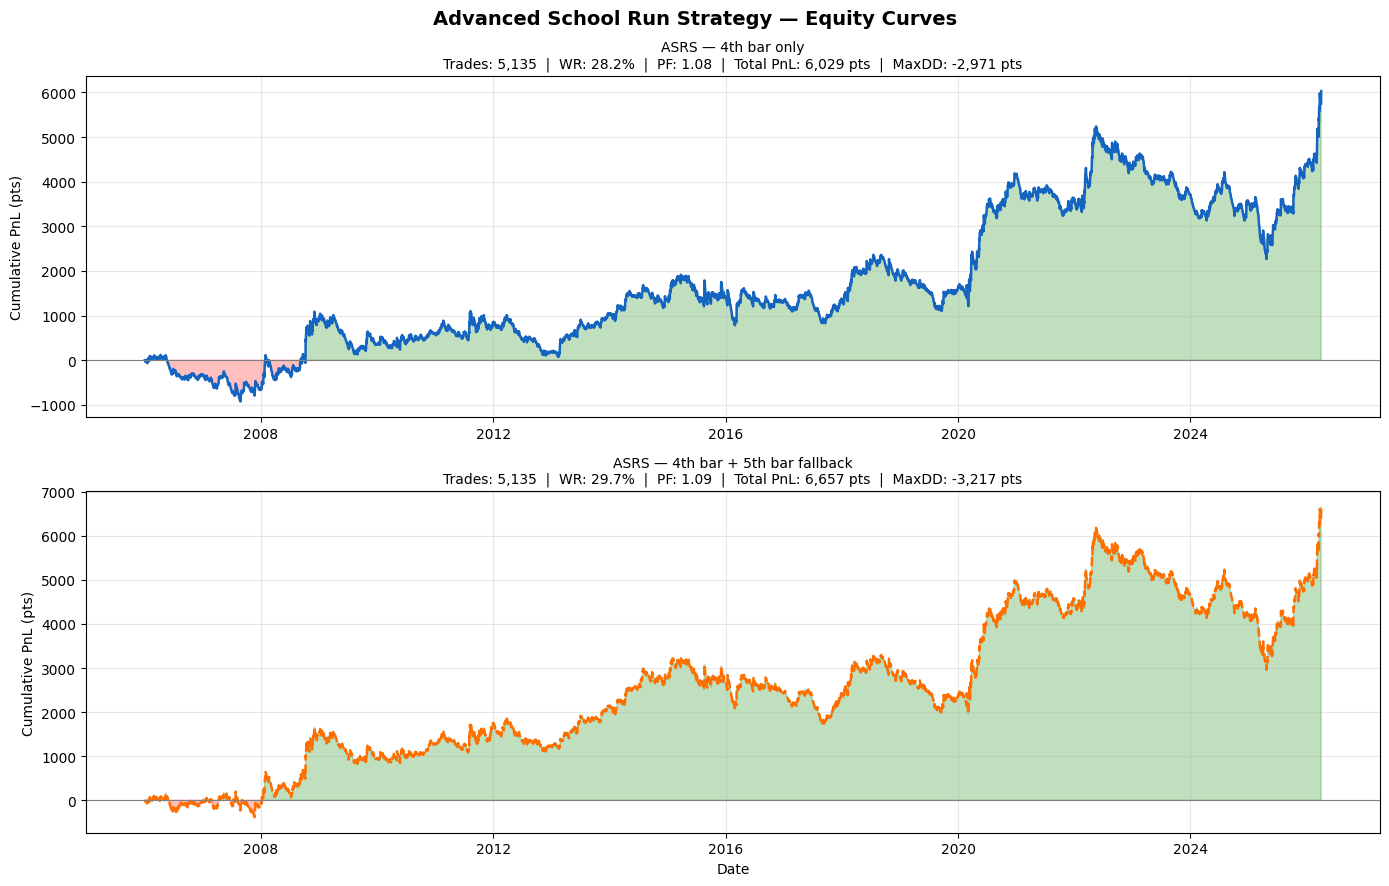

Saved: asrs_equity_curves.png


In [14]:
# Figure 1: Equity curves comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle('Advanced School Run Strategy — Equity Curves', fontsize=14, fontweight='bold')

labels_colors = [
    ('ASRS_4th',              '#1565C0', '-',  'ASRS — 4th bar only'),
    ('ASRS_4th_5th_fallback', '#FF6F00', '--', 'ASRS — 4th bar + 5th bar fallback'),
]

for ax_idx, (ax, (key, color, ls, label)) in enumerate(zip(axes, labels_colors)):
    df_v = results[key]
    cum  = df_v['pnl'].cumsum()
    ax.fill_between(cum.index, cum.values, 0,
                    where=cum.values >= 0, alpha=0.25, color='green')
    ax.fill_between(cum.index, cum.values, 0,
                    where=cum.values  < 0, alpha=0.25, color='red')
    ax.plot(cum.index, cum.values, color=color, lw=1.8, ls=ls)
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_ylabel('Cumulative PnL (pts)')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    m = compute_metrics(df_v)
    info = (f"Trades: {m['n_trades']:,}  |  WR: {m['win_rate_%']}%  |  "
            f"PF: {m['profit_factor']}  |  Total PnL: {m['total_pnl_pts']:,.0f} pts  |  "
            f"MaxDD: {m['max_dd_pts']:,.0f} pts")
    ax.set_title(f"{label}\n{info}", fontsize=10)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig(ROOT / 'data' / 'asrs_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_equity_curves.png')

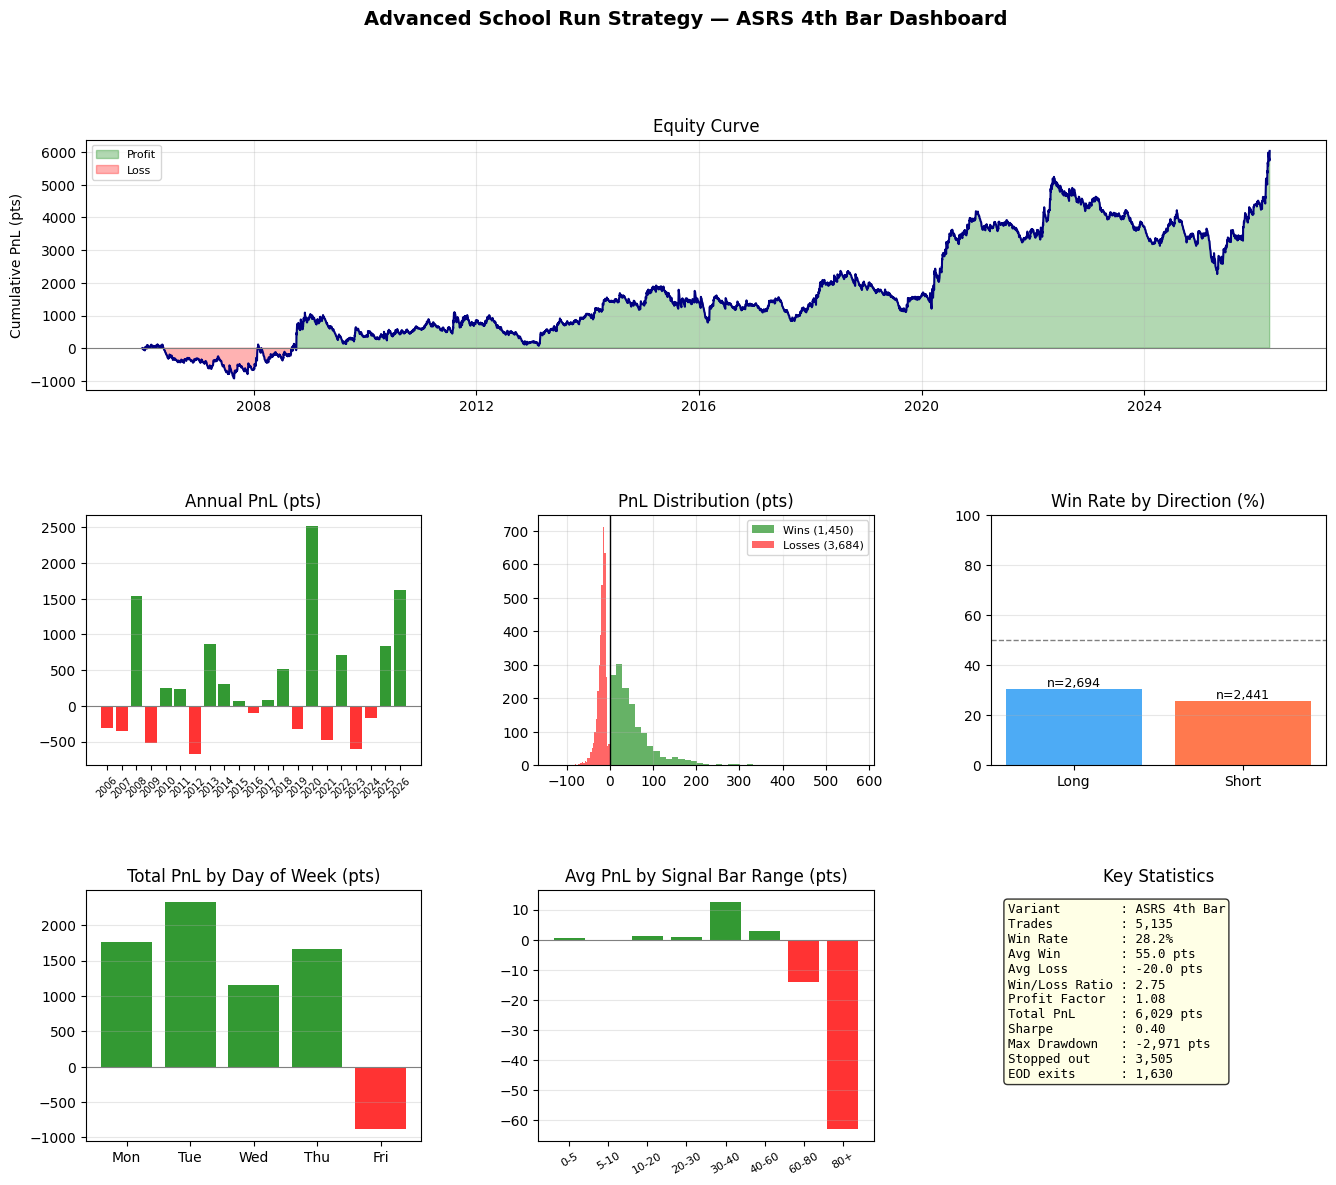

Saved: asrs_dashboard.png


In [15]:
# Figure 2: Full Dashboard (base variant)
m = compute_metrics(df_base, label='ASRS_4th')

fig = plt.figure(figsize=(16, 13))
fig.suptitle('Advanced School Run Strategy — ASRS 4th Bar Dashboard', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# 1. Equity curve
ax1 = fig.add_subplot(gs[0, :])
cum = df_base['pnl'].cumsum()
ax1.fill_between(cum.index, cum.values, 0, where=cum.values >= 0, alpha=0.3, color='green', label='Profit')
ax1.fill_between(cum.index, cum.values, 0, where=cum.values  < 0, alpha=0.3, color='red',   label='Loss')
ax1.plot(cum.index, cum.values, color='navy', lw=1.5)
ax1.axhline(0, color='gray', lw=0.8)
ax1.set_ylabel('Cumulative PnL (pts)')
ax1.set_title('Equity Curve')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 2. Annual PnL
ax2 = fig.add_subplot(gs[1, 0])
ann_colors = ['green' if v > 0 else 'red' for v in annual['total_pnl']]
ax2.bar(annual.index.astype(str), annual['total_pnl'], color=ann_colors, alpha=0.8)
ax2.axhline(0, color='gray', lw=0.8)
ax2.set_title('Annual PnL (pts)')
ax2.tick_params(axis='x', rotation=45, labelsize=7)
ax2.grid(True, axis='y', alpha=0.3)

# 3. PnL distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(winners_only['pnl'], bins=40, color='green', alpha=0.6, label=f'Wins ({len(winners_only):,})')
ax3.hist(losers_only ['pnl'], bins=40, color='red',   alpha=0.6, label=f'Losses ({len(losers_only):,})')
ax3.axvline(0, color='black', lw=1)
ax3.set_title('PnL Distribution (pts)')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)

# 4. Win rate by direction
ax4 = fig.add_subplot(gs[1, 2])
bars_wr = ax4.bar(['Long', 'Short'], [m['wr_long_%'], m['wr_short_%']],
                  color=['#2196F3', '#FF5722'], alpha=0.8)
ax4.set_ylim(0, 100)
ax4.axhline(50, color='gray', ls='--', lw=1)
ax4.set_title('Win Rate by Direction (%)')
for bar_p, n in zip(bars_wr, [m['n_longs'], m['n_shorts']]):
    ax4.text(bar_p.get_x() + bar_p.get_width()/2, bar_p.get_height() + 1,
             f'n={n:,}', ha='center', fontsize=9)
ax4.grid(True, axis='y', alpha=0.3)

# 5. Day-of-week performance
ax5 = fig.add_subplot(gs[2, 0])
dow_colors = ['green' if v > 0 else 'red' for v in dow_perf['total_pnl']]
ax5.bar(dow_perf.index, dow_perf['total_pnl'], color=dow_colors, alpha=0.8)
ax5.axhline(0, color='gray', lw=0.8)
ax5.set_title('Total PnL by Day of Week (pts)')
ax5.grid(True, axis='y', alpha=0.3)

# 6. Signal bar range vs avg PnL
ax6 = fig.add_subplot(gs[2, 1])
x_labels = [str(b) for b in bar_size_perf.index]
bar_colors6 = ['green' if v > 0 else 'red' for v in bar_size_perf['avg_pnl']]
ax6.bar(range(len(x_labels)), bar_size_perf['avg_pnl'], color=bar_colors6, alpha=0.8)
ax6.set_xticks(range(len(x_labels)))
ax6.set_xticklabels(x_labels, fontsize=8, rotation=30)
ax6.axhline(0, color='gray', lw=0.8)
ax6.set_title('Avg PnL by Signal Bar Range (pts)')
ax6.grid(True, axis='y', alpha=0.3)

# 7. Key stats
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
stats_text = (
    f"Variant        : ASRS 4th Bar\n"
    f"Trades         : {m['n_trades']:,}\n"
    f"Win Rate       : {m['win_rate_%']}%\n"
    f"Avg Win        : {m['avg_win_pts']:.1f} pts\n"
    f"Avg Loss       : {m['avg_loss_pts']:.1f} pts\n"
    f"Win/Loss Ratio : {m['win_loss_ratio']:.2f}\n"
    f"Profit Factor  : {m['profit_factor']:.2f}\n"
    f"Total PnL      : {m['total_pnl_pts']:,.0f} pts\n"
    f"Sharpe         : {m['sharpe']:.2f}\n"
    f"Max Drawdown   : {m['max_dd_pts']:,.0f} pts\n"
    f"Stopped out    : {m['n_stopped']:,}\n"
    f"EOD exits      : {m['n_eod']:,}"
)
ax7.text(0.05, 0.95, stats_text, transform=ax7.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax7.set_title('Key Statistics')

plt.savefig(ROOT / 'data' / 'asrs_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_dashboard.png')

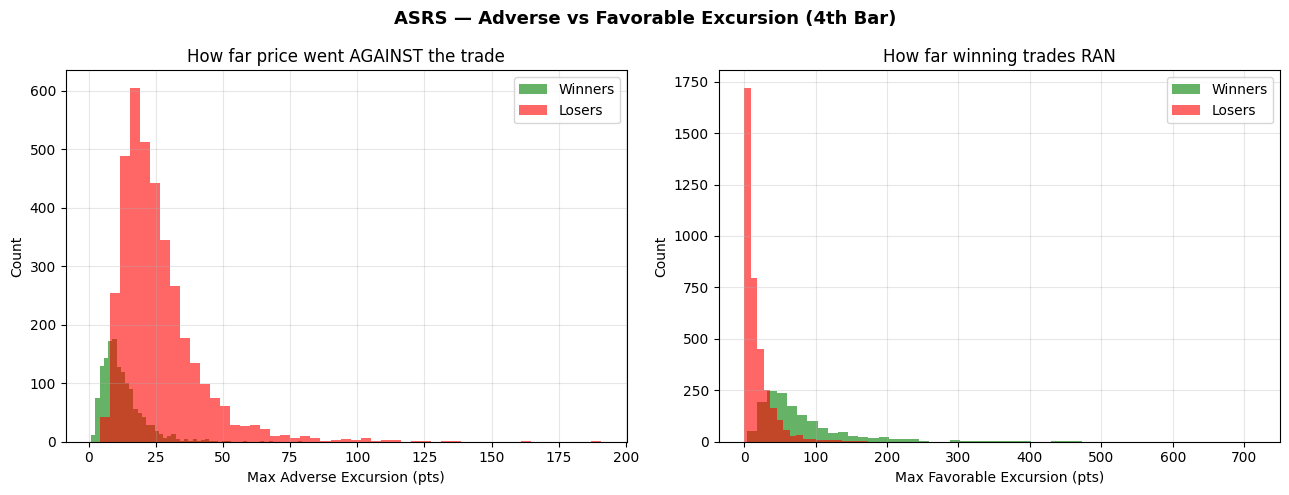

Saved: asrs_excursion.png


In [16]:
# Figure 3: Adverse & Favorable Excursion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ASRS — Adverse vs Favorable Excursion (4th Bar)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(winners_only['max_adverse'], bins=50, color='green', alpha=0.6, label='Winners')
ax.hist(losers_only ['max_adverse'], bins=50, color='red',   alpha=0.6, label='Losers')
ax.set_xlabel('Max Adverse Excursion (pts)')
ax.set_ylabel('Count')
ax.set_title('How far price went AGAINST the trade')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(winners_only['max_favorable'], bins=50, color='green', alpha=0.6, label='Winners')
ax.hist(losers_only ['max_favorable'], bins=50, color='red',   alpha=0.6, label='Losers')
ax.set_xlabel('Max Favorable Excursion (pts)')
ax.set_ylabel('Count')
ax.set_title('How far winning trades RAN')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'asrs_excursion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_excursion.png')

## 9. Export Results

In [17]:
# Export all trades
frames = []
for key, df in results.items():
    tmp = df.copy()
    tmp['variant'] = key
    frames.append(tmp.reset_index())

all_trades = pd.concat(frames, ignore_index=True)
trades_path = ROOT / 'data' / 'asrs_trades_all.csv'
all_trades.to_csv(trades_path, index=False)
print(f'Exported {len(all_trades):,} rows → {trades_path}')

summary_path = ROOT / 'data' / 'asrs_summary.csv'
summary.to_csv(summary_path)
print(f'Exported summary → {summary_path}')

print('\n=== FINAL SUMMARY ===')
print(summary[cols_display].to_string())

Exported 10,270 rows → c:\Users\ali\Desktop\Projet-INFO-2AS2\data\asrs_trades_all.csv
Exported summary → c:\Users\ali\Desktop\Projet-INFO-2AS2\data\asrs_summary.csv

=== FINAL SUMMARY ===
                       n_trades  win_rate_%  avg_win_pts  avg_loss_pts  win_loss_ratio  profit_factor  total_pnl_pts  sharpe  max_dd_pts  wr_long_%  wr_short_%
label                                                                                                                                                          
ASRS_4th                   5135        28.2         55.0         -20.0            2.75           1.08         6029.0    0.40     -2971.0       30.6        25.6
ASRS_4th_5th_fallback      5135        29.7         53.3         -20.6            2.58           1.09         6657.0    0.44     -3217.0       32.3        26.8
